#Capstone Project 3: Liver Patients Dataset

#Executive Summary

Patients with Liver disease have been continuously increasing because of excessive consumption of alcohol, inhale of harmful gases, intake of contaminated food, pickles and drugs. This dataset was used to evaluate prediction algorithms in an effort to reduce burden on doctors.

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve,f1_score,roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV,learning_curve,cross_val_score
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.calibration import calibration_curve

In [ ]:
# Define column names based on dataset description
columns = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase", "Total_Proteins",
    "Albumin", "Albumin_and_Globulin_Ratio", "Target"
]

# Load CSV with custom headers
liver = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None, names=columns)
liver.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
liver.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


In [ ]:
# Assuming liver['Target'] has values 1 (disease) and 2 (no disease)
liver['Target'] = liver['Target'].map({1:1, 2:0})  # disease=1, no disease=0
liver.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


#EDA

**Definition:** Exploratory Data Analysis (EDA) is the process of examining and summarizing a dataset to uncover its main characteristics, patterns, anomalies, and relationships before applying formal modeling or hypothesis testing. It is the “first look” at data, often using visualizations and descriptive statistics.

In [ ]:
liver.shape #to know the number of data and column

(583, 11)

In [ ]:
liver.info() #to know about the complete information of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [ ]:
liver.describe #to know the statistical variations like standard deviation, minimum value, IQR

<bound method NDFrame.describe of      Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0     65  Female              0.7               0.1                   187   
1     62    Male             10.9               5.5                   699   
2     62    Male              7.3               4.1                   490   
3     58    Male              1.0               0.4                   182   
4     72    Male              3.9               2.0                   195   
..   ...     ...              ...               ...                   ...   
578   60    Male              0.5               0.1                   500   
579   40    Male              0.6               0.1                    98   
580   52    Male              0.8               0.2                   245   
581   31    Male              1.3               0.5                   184   
582   38    Male              1.0               0.3                   216   

     Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Proteins  \
0                          16                          18             6.8   
1                          64                         100             7.5   
2                          60                          68             7.0   
3                          14                          20             6.8   
4                          27                          59             7.3   
..                        ...                         ...             ...   
578                        20                          34             5.9   
579                        35                          31             6.0   
580                        48                          49             6.4   
581                        29                          32             6.8   
582                        21                          24             7.3   

     Albumin  Albumin_and_Globulin_Ratio  Target  
0        3.3                        0.90       1  
1        3.2                        0.74       1  
2        3.3                        0.89       1  
3        3.4                        1.00       1  
4        2.4                        0.40       1  
..       ...                         ...     ...  
578      1.6                        0.37       0  
579      3.2                        1.10       1  
580      3.2                        1.00       1  
581      3.4                        1.00       1  
582      4.4                        1.50       0  

[583 rows x 11 columns]>

In [ ]:
liver.isnull().sum() #to know the null variables

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Proteins,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [ ]:
liver['Albumin_and_Globulin_Ratio'].fillna(liver['Albumin_and_Globulin_Ratio'].median(), inplace=True)
liver.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Proteins,0
Albumin,0
Albumin_and_Globulin_Ratio,0


In [ ]:
liver.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Target'],
      dtype='object')

In [ ]:
num_cols = ['Age', 'Total_Bilirubin', 'Direct_Bilirubin',
            'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
            'Aspartate_Aminotransferase', 'Total_Proteins',
            'Albumin', 'Albumin_and_Globulin_Ratio']

cat_cols = ['Gender']

#Preprocessing: scale numeric + encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

#Feature Engineering

Feature engineering is the process of creating new input variables (features) or transforming existing ones to improve the performance of machine learning models. It uses domain knowledge and statistical techniques to highlight important relationships in the data, reduce noise, and make patterns easier for algorithms to learn.

In [ ]:
# Copy dataset
liver_fe = liver.copy()

# 1. Age bins
liver_fe['Age_Bin'] = pd.cut(liver_fe['Age'], bins=[0,30,50,70,100], labels=['Young','Middle','Senior','Elder'])

# 2. Bilirubin ratio
liver_fe['Bilirubin_Ratio'] = liver_fe['Direct_Bilirubin'] / liver_fe['Total_Bilirubin']

# 3. Enzyme ratio
liver_fe['Enzyme_Ratio'] = liver_fe['Aspartate_Aminotransferase'] / liver_fe['Alamine_Aminotransferase']

# 4. Protein balance
liver_fe['Protein_Balance'] = liver_fe['Albumin'] / liver_fe['Total_Proteins']

# 5. Log transform skewed feature
liver_fe['Log_Alkaline_Phosphotase'] = np.log1p(liver_fe['Alkaline_Phosphotase'])

# 6. Interaction feature
liver_fe['Age_AlbuminRatio'] = liver_fe['Age'] * liver_fe['Albumin_and_Globulin_Ratio']

print(liver_fe.head())

   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
1   62    Male             10.9               5.5                   699   
2   62    Male              7.3               4.1                   490   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Proteins  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   Albumin  Albumin_and_Globulin_Ratio  Target Age_Bin  Bilirubin_Ratio  \
0      3.3             

Explaination

Feature engineering is used to create new, more meaningful variables from existing data so the model can learn patterns more effectively. In this project, we added features such as Age bins (grouping patients into categories), ratios (Direct_Bilirubin ÷ Total_Bilirubin, enzyme ratios), log transformations (to reduce skewness in Alkaline_Phosphatase), and interaction features (Age × Albumin_and_Globulin_Ratio). These engineered features highlight hidden relationships in the medical data, improve model accuracy, and make the results easier to interpret.

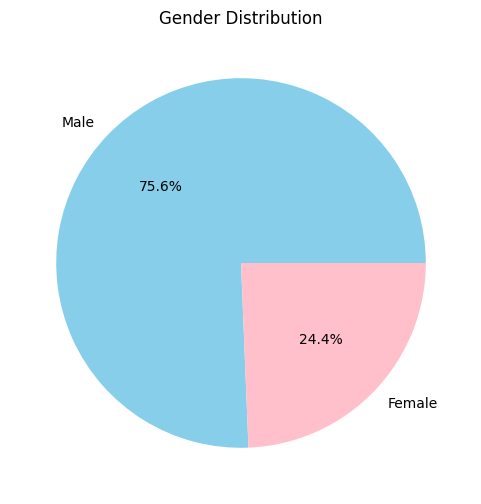

In [ ]:
# Count the values in the Gender column
gender = liver['Gender'].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(
    gender,
    labels=gender.index,
     colors=["skyblue","pink"],   # corrected argument name
    autopct='%1.1f%%'         # optional: show percentages
)
plt.title("Gender Distribution")
plt.show()

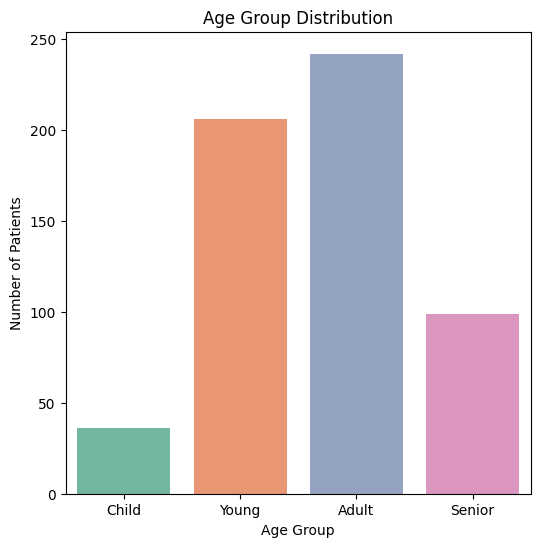

In [ ]:
# Create age groups
bins = [0, 18, 40, 60, 90]
labels = ['Child','Young','Adult','Senior']
liver['Age_Group'] = pd.cut(liver['Age'], bins=bins, labels=labels)

# Countplot
plt.figure(figsize=(6,6))
sns.countplot(x='Age_Group', data=liver, palette="Set2")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
print(liver.columns)

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Target', 'Age_Group'],
      dtype='object')


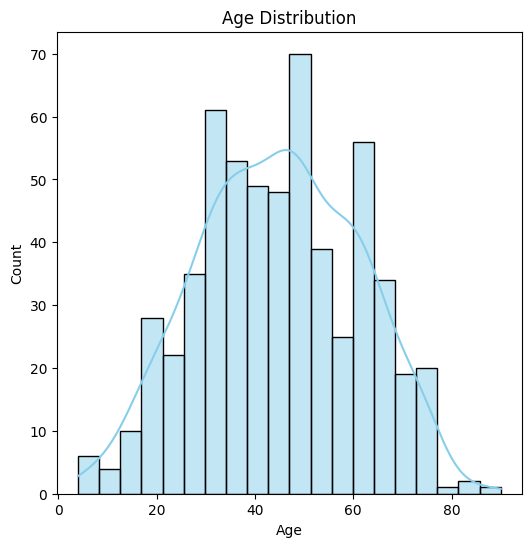

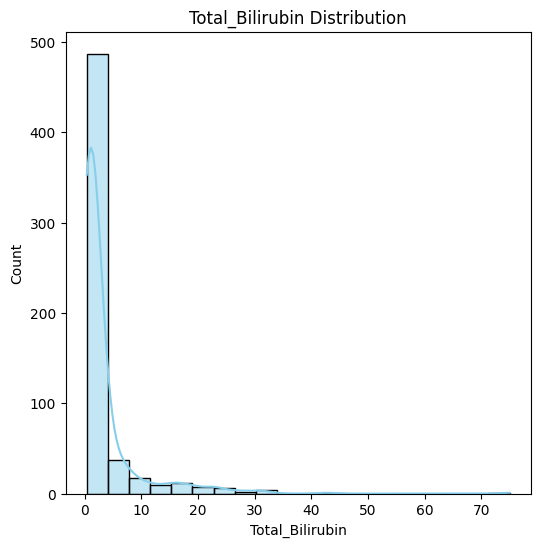

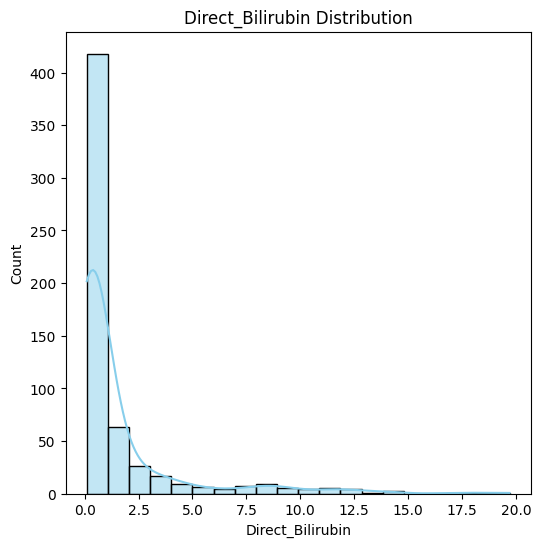

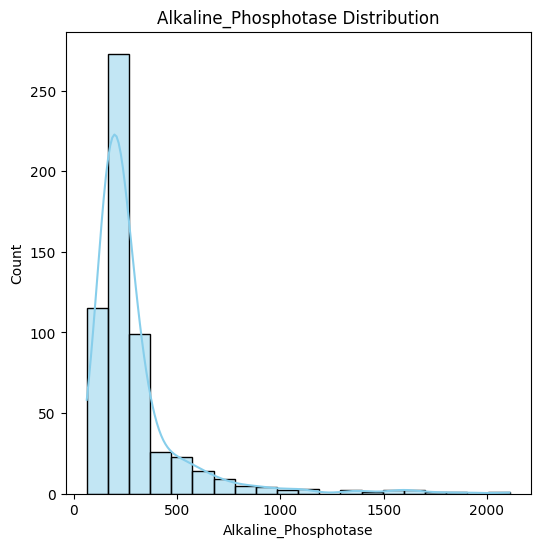

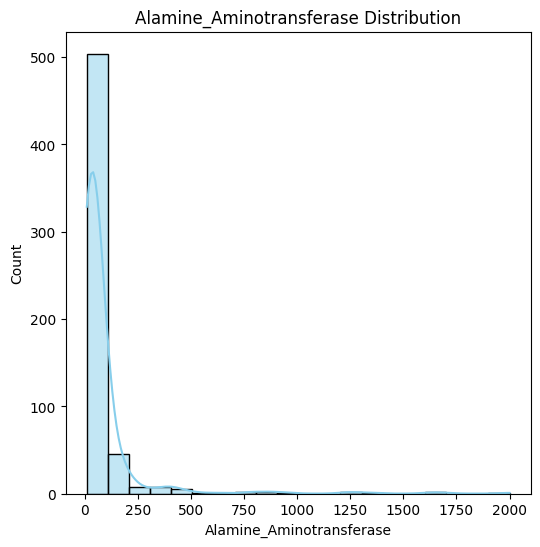

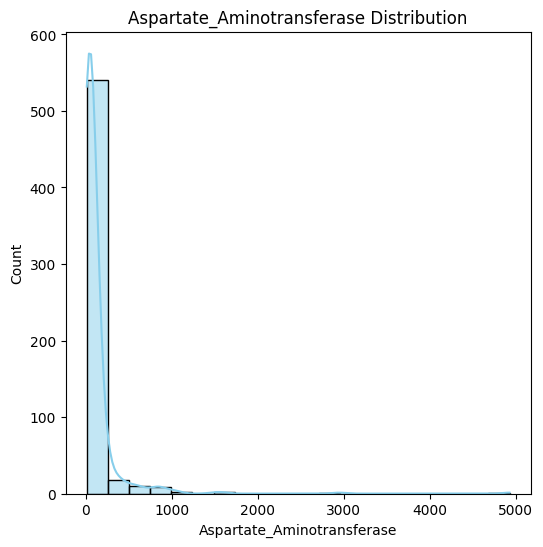

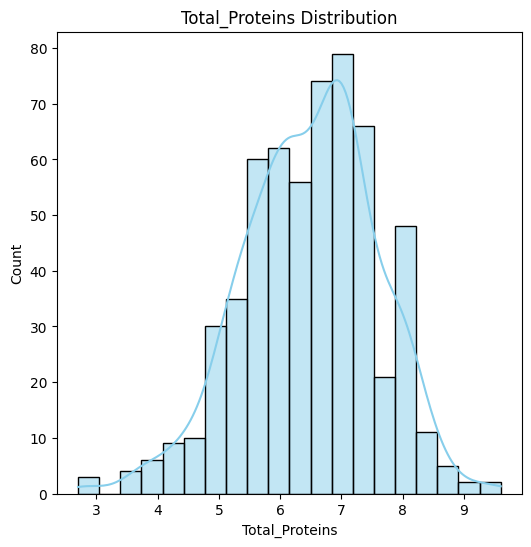

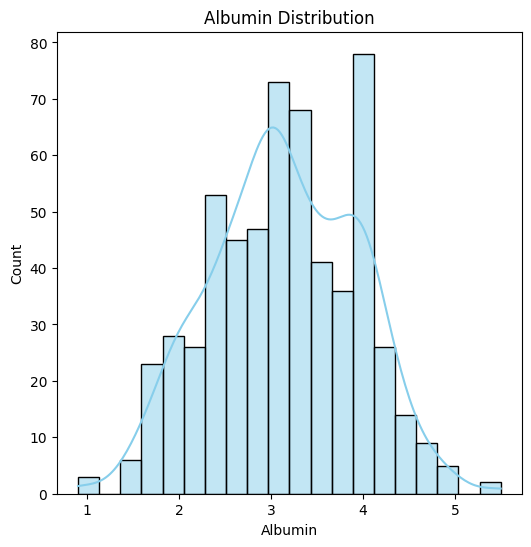

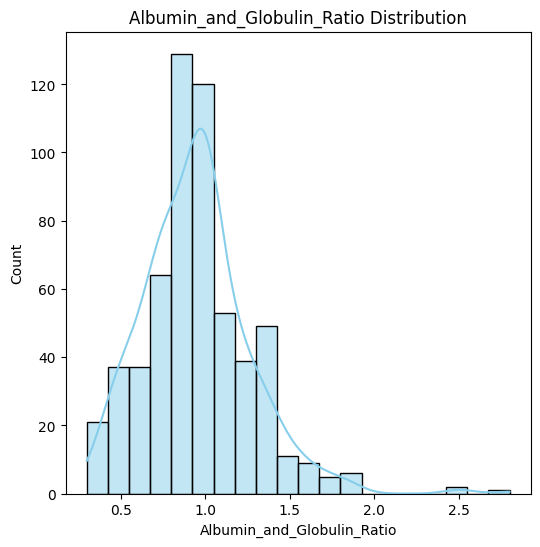

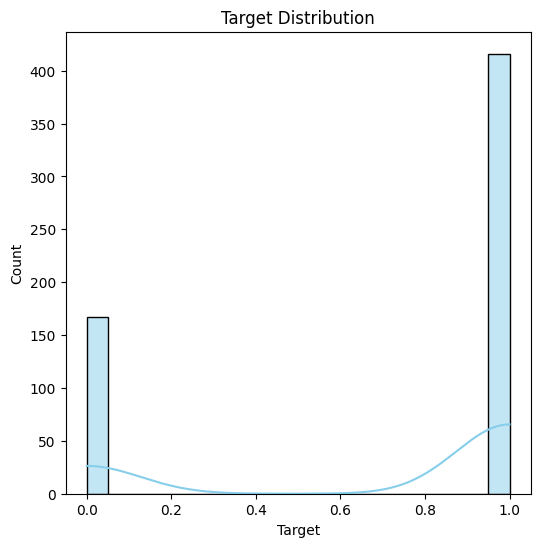

In [ ]:
num_cols = liver.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,6))
    sns.histplot(liver[col], bins=20, kde=True, color='skyblue')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

#Logistic Regression

Logistic Regression is a statistical and machine learning technique used for binary classification, where the outcome has two possible categories (such as yes/no or 0/1). It works by modeling the relationship between input features and the probability of belonging to one class using the sigmoid function, which maps values into a range between 0 and 1. This makes it especially useful when you want interpretable results, as its coefficients can be understood as how each feature influences the odds of an outcome. In short, Logistic Regression is a simple, efficient, and widely used method for predicting probabilities in classification problems.

Why it is using here?

Logistic Regression is used here because your dataset is a binary classification problem — predicting whether a patient has liver disease (1) or not (0). It applies the sigmoid function to map values into probabilities between 0 and 1, making it ideal for medical contexts where risk levels matter. The method is simple, efficient, and interpretable, allowing you to see how features like age, gender, or bilirubin levels influence the odds of disease, while still giving probability‑based predictions that are easy to evaluate with metrics like ROC‑AUC and F1‑score.

In [ ]:
liver.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target,Age_Group
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1,Senior
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1,Senior
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1,Senior
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1,Adult
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1,Senior


In [ ]:
# One-Hot Encode categorical variables
# Identify categorical columns to encode
categorical_cols = ['Gender', 'Age_Group']

# Perform one-hot encoding on the specified categorical columns, keeping all other columns
liver_encoded = pd.get_dummies(liver, columns=categorical_cols, drop_first=True)

In [ ]:
X = liver_encoded.drop('Target', axis=1)   # all features except outcome
y = liver_encoded['Target']                # outcome variable

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train.shape

(466, 13)

In [ ]:
X_test.shape

(117, 13)

In [ ]:
# Logistic Regression with class weights
log_reg_1 = LogisticRegression(max_iter=1000, random_state=42)
log_reg_1.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
log_reg_1.fit(X_train, y_train)
y_pred= log_reg_1.predict(X_test)
print("Accuracy_Score:",accuracy_score(y_test,y_pred))
print("Classification_report:\n",classification_report(y_test,y_pred))
print("Confusion_Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy_Score: 0.7350427350427351
Classification_report:
               precision    recall  f1-score   support

           0       0.60      0.26      0.37        34
           1       0.75      0.93      0.83        83

    accuracy                           0.74       117
   macro avg       0.68      0.60      0.60       117
weighted avg       0.71      0.74      0.70       117

Confusion_Matrix:
 [[ 9 25]
 [ 6 77]]


In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_prob= log_reg.predict_proba(X_test)[:,1]

# Find best threshold
thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores = [(t, f1_score(y_test, (y_prob >= t).astype(int))) for t in thresholds]
best_thresh, best_f1 = max(f1_scores, key=lambda x: x[1])

# Evaluate at best threshold
y_pred_best = (y_prob >= best_thresh).astype(int)
print(f"Best threshold: {best_thresh:.2f} with F1 score: {best_f1:.3f}")
print("Classification Report:\n", classification_report(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Best threshold: 0.60 with F1 score: 0.842
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.53      0.57        34
           1       0.82      0.87      0.84        83

    accuracy                           0.77       117
   macro avg       0.72      0.70      0.71       117
weighted avg       0.76      0.77      0.76       117

Accuracy: 0.7692307692307693
Confusion Matrix:
 [[18 16]
 [11 72]]


#SMOTE

SMOTE (Synthetic Minority Oversampling Technique) is a method used to handle class imbalance in datasets. Instead of simply duplicating minority class samples, SMOTE creates synthetic new samples by interpolating between existing minority points. This increases the representation of the minority class and makes the dataset balanced.

#Analysis

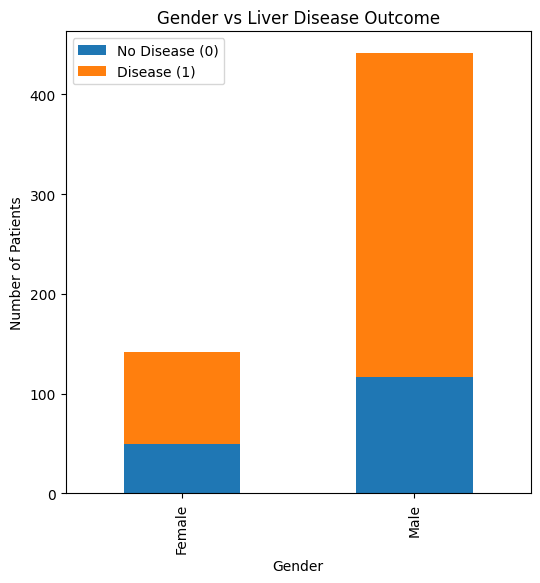

In [ ]:
# Crosstab without forcing missing categories
gender_disease = pd.crosstab(liver['Gender'], liver['Target'])

# Plot stacked bar chart
gender_disease.plot(kind='bar', stacked=True, figsize=(6,6))
plt.title("Gender vs Liver Disease Outcome")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.legend(["No Disease (0)", "Disease (1)"])
autopct='%1.1f%%'
plt.show()

#Explaination

“The stacked bar chart of gender versus liver disease outcome visually highlights the distribution of patients across male and female categories, while simultaneously showing the proportion of those diagnosed with liver disease compared to those without. This helps identify demographic imbalances in the dataset and provides insight into whether gender plays a role in disease prevalence, which is important for both exploratory data analysis and guiding predictive model design.”

Why SMOTE is using here?

SMOTE (Synthetic Minority Oversampling Technique) is used here because your dataset is imbalanced, with far fewer “No Disease” cases compared to “Disease.” This imbalance causes the model to favor the majority class, leading to poor recall for the minority class as seen in the confusion matrix and classification report. By generating synthetic samples for the minority class, SMOTE balances the dataset, helps the model learn patterns from both classes fairly, and improves its ability to correctly classify both outcomes, resulting in more reliable and unbiased predictions.

In [ ]:
liver['Gender'].value_counts()

,count
Gender,
Male,441
Female,142


In [ ]:
liver['Target'].value_counts()

,count
Target,
1,416
0,167


In [ ]:
#Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({1: 333, 0: 133})
After SMOTE: Counter({1: 333, 0: 333})


In [ ]:
log_reg_smote = LogisticRegression(random_state=42, max_iter=1000)
log_reg_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
log_reg_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = log_reg_smote.predict(X_test)
print("Accuracy_Score:", accuracy_score(y_test,y_pred_smote))
print("Classification_Report:\n", classification_report(y_test,y_pred_smote))
print("Confusion_Matrix:\n", confusion_matrix(y_test,y_pred_smote))

Accuracy_Score: 0.7350427350427351
Classification_Report:
               precision    recall  f1-score   support

           0       0.53      0.71      0.61        34
           1       0.86      0.75      0.80        83

    accuracy                           0.74       117
   macro avg       0.70      0.73      0.70       117
weighted avg       0.77      0.74      0.74       117

Confusion_Matrix:
 [[24 10]
 [21 62]]


In [ ]:
y_prob_smote= log_reg_smote.predict_proba(X_test)[:,1]

# Find best threshold
thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores = [(t, f1_score(y_test, (y_prob_smote >= t).astype(int))) for t in thresholds]
best_thresh, best_f1 = max(f1_scores, key=lambda x: x[1])

# Evaluate at best threshold
y_pred_best_smote = (y_prob_smote >= best_thresh).astype(int)
print(f"Best threshold: {best_thresh:.2f} with F1 score: {best_f1:.3f}")
print("Classification Report:\n", classification_report(y_test, y_pred_best_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_best_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_smote))

Best threshold: 0.20 with F1 score: 0.831
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.09      0.15        34
           1       0.72      0.98      0.83        83

    accuracy                           0.72       117
   macro avg       0.66      0.53      0.49       117
weighted avg       0.69      0.72      0.63       117

Accuracy: 0.717948717948718
Confusion Matrix:
 [[ 3 31]
 [ 2 81]]


#Comparison before and after SMOTE

#Before SMOTE

Without Threshold

In [ ]:
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print("Accuracy_Score:", accuracy_score(y_test,y_pred))
print("Classification_Report:\n", classification_report(y_test,y_pred))
print("Confusion_Matrix:\n", confusion_matrix(y_test,y_pred))

Accuracy_Score: 0.7350427350427351
Classification_Report:
               precision    recall  f1-score   support

           0       0.60      0.26      0.37        34
           1       0.75      0.93      0.83        83

    accuracy                           0.74       117
   macro avg       0.68      0.60      0.60       117
weighted avg       0.71      0.74      0.70       117

Confusion_Matrix:
 [[ 9 25]
 [ 6 77]]


With Threshold (Before SMOTE)

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_prob= log_reg.predict_proba(X_test)[:,1]

# Find best threshold
thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores = [(t, f1_score(y_test, (y_prob >= t).astype(int))) for t in thresholds]
best_thresh, best_f1 = max(f1_scores, key=lambda x: x[1])

# Evaluate at best threshold
y_pred_best = (y_prob >= best_thresh).astype(int)
print(f"Best threshold: {best_thresh:.2f} with F1 score: {best_f1:.3f}")
print("Classification Report:\n", classification_report(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Best threshold: 0.60 with F1 score: 0.842
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.53      0.57        34
           1       0.82      0.87      0.84        83

    accuracy                           0.77       117
   macro avg       0.72      0.70      0.71       117
weighted avg       0.76      0.77      0.76       117

Accuracy: 0.7692307692307693
Confusion Matrix:
 [[18 16]
 [11 72]]


#Explaination

***Before SMOTE***

The dataset was imbalanced, with class 1 dominating.

Accuracy ~73–74%, but this was misleading because the model favored the majority class.

**1. Class 0 (minority):**

Precision ~0.60, Recall ~0.26 → very poor detection.

Most class 0 samples were misclassified as class 1.

**2. Class 1 (majority):**

Precision ~0.75, Recall ~0.93 → strong detection.

**Confusion Matrix showed:** 25 false negatives for class 0, meaning minority cases were ignored.

**Interpretation:** The model was biased toward the majority class, achieving good accuracy but failing to identify minority cases.

***Threshold Tuning***

**Before SMOTE:** Best threshold ~0.60 gave F1 ~0.842. Balanced precision/recall for class 1, but class 0 recall remained weak.

#After SMOTE

Without Threshold

In [ ]:
log_reg_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = log_reg_smote.predict(X_test)
print("Accuracy_Score:", accuracy_score(y_test,y_pred_smote))
print("Classification_Report:\n", classification_report(y_test,y_pred_smote))
print("Confusion_Matrix:\n", confusion_matrix(y_test,y_pred_smote))

Accuracy_Score: 0.7350427350427351
Classification_Report:
               precision    recall  f1-score   support

           0       0.53      0.71      0.61        34
           1       0.86      0.75      0.80        83

    accuracy                           0.74       117
   macro avg       0.70      0.73      0.70       117
weighted avg       0.77      0.74      0.74       117

Confusion_Matrix:
 [[24 10]
 [21 62]]


With Threshold

In [ ]:
y_prob_smote= log_reg_smote.predict_proba(X_test)[:,1]

# Find best threshold
thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores = [(t, f1_score(y_test, (y_prob_smote >= t).astype(int))) for t in thresholds]
best_thresh, best_f1 = max(f1_scores, key=lambda x: x[1])

# Evaluate at best threshold
y_pred_best_smote = (y_prob_smote >= best_thresh).astype(int)
print(f"Best threshold: {best_thresh:.2f} with F1 score: {best_f1:.3f}")
print("Classification Report:\n", classification_report(y_test, y_pred_best_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_best_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_smote))

Best threshold: 0.20 with F1 score: 0.831
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.09      0.15        34
           1       0.72      0.98      0.83        83

    accuracy                           0.72       117
   macro avg       0.66      0.53      0.49       117
weighted avg       0.69      0.72      0.63       117

Accuracy: 0.717948717948718
Confusion Matrix:
 [[ 3 31]
 [ 2 81]]


#Explaination

***After SMOTE***

Dataset was balanced using synthetic samples.

Accuracy ~73–74%, similar to before, but distribution of errors changed.

**1. Class 0 (minority):**

Precision ~0.53, Recall ~0.71 → recall improved significantly.

More minority cases were correctly identified.

**2. Class 1 (majority):**

Precision ~0.86, Recall ~0.75 → recall dropped slightly, but precision improved.

**Confusion Matrix showed:** fewer false negatives for class 0 compared to before.

**Interpretation:** SMOTE improved fairness by boosting minority recall, though it slightly reduced majority recall.

***Threshold Tuning***

**After SMOTE:** Best threshold ~0.20 gave F1 ~0.831. Recall for class 1 improved, but class 0 recall dropped sharply (to ~0.09).

**Interpretation:**

#Interpretation

Threshold tuning optimizes F1, but the trade‑off differs. Before SMOTE, threshold tuning helped majority class more. After SMOTE, threshold tuning favored recall for class 1 but hurt minority detection.

#Random Forest

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their outputs (through majority voting for classification or averaging for regression). By aggregating many trees, it reduces overfitting, improves accuracy, and provides a more stable and robust model compared to a single decision tree.

In [ ]:
liver.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Target', 'Age_Group'],
      dtype='object')

In [ ]:
# 1. Split features and target
X = liver.drop("Target", axis=1)
y = liver["Target"]

num_cols = ['Age','Total_Bilirubin','Direct_Bilirubin',
            'Alkaline_Phosphotase','Alamine_Aminotransferase',
            'Aspartate_Aminotransferase','Total_Proteins',
            'Albumin','Albumin_and_Globulin_Ratio']

cat_cols = ['Gender','Age_Group']

# 2. Preprocessor: scale numeric + encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Apply preprocessing first
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# 5. Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

# 6. Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train_res, y_train_res)

# 7. Evaluate
y_pred_rf = rf.predict(X_test_prep)
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.44      0.48        34
           1       0.78      0.83      0.81        83

    accuracy                           0.72       117
   macro avg       0.65      0.64      0.64       117
weighted avg       0.71      0.72      0.71       117

Confusion Matrix:
 [[15 19]
 [14 69]]
Accuracy Score: 0.717948717948718


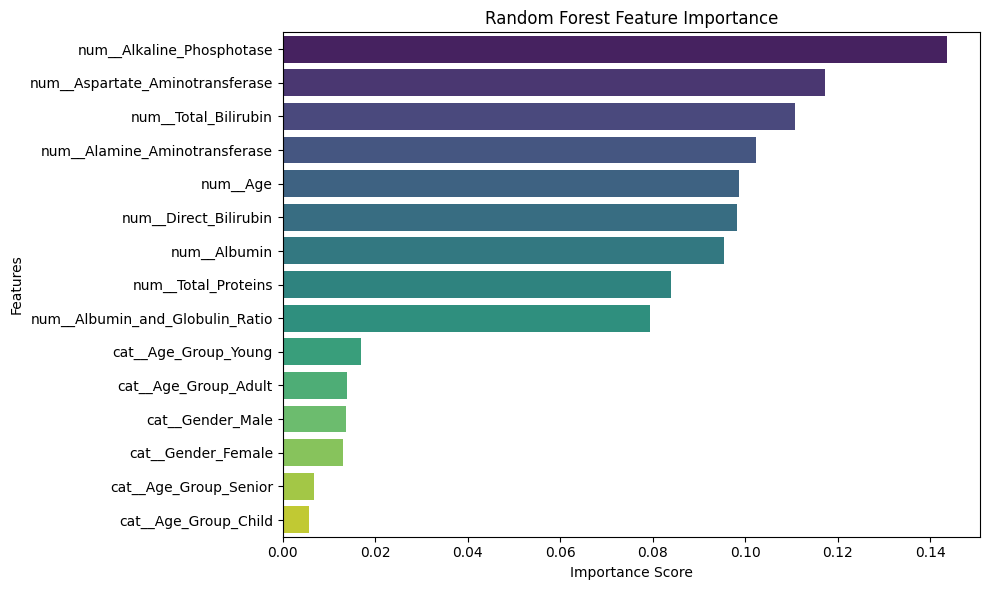

In [ ]:
# --- Feature Importance ---
importances = rf.feature_importances_
feature_names = preprocessor.get_feature_names_out()

# Sort by importance
indices = importances.argsort()[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

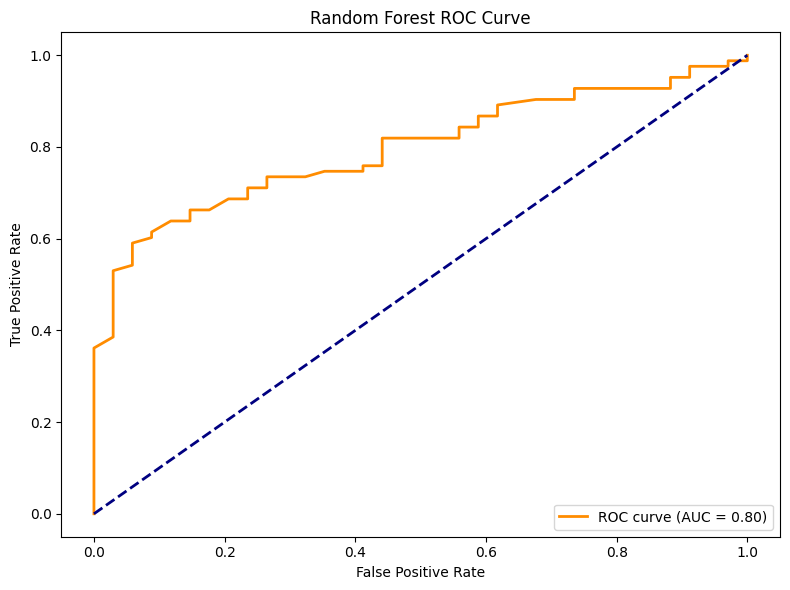

In [ ]:
# --- ROC Curve ---
y_proba_rf = rf.predict_proba(X_test_prep)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#XG Booster

XGBoost (Extreme Gradient Boosting) is an open‑source machine learning library that implements an optimized version of gradient boosting, designed for speed, accuracy, and scalability. It is widely used in data science competitions and industry applications because it consistently delivers high performance on structured/tabular datasets.

In [ ]:
# --- Load dataset ---
X = liver.drop("Target", axis=1)
y = liver["Target"]

# --- Define numeric and categorical columns ---
num_cols = ['Age','Total_Bilirubin','Direct_Bilirubin',
            'Alkaline_Phosphotase','Alamine_Aminotransferase',
            'Aspartate_Aminotransferase','Total_Proteins',
            'Albumin','Albumin_and_Globulin_Ratio']
cat_cols = ['Gender','Age_Group']

# --- Preprocessing ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# --- Handle imbalance with SMOTE ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

# --- Train XGBoost ---
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    scale_pos_weight=1,   # can adjust for imbalance if needed
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train_res, y_train_res)

# --- Evaluate ---
y_pred_xgb = xgb.predict(X_test_prep)
y_proba_xgb = xgb.predict_proba(X_test_prep)[:,1]

print("=== XGBoost Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

=== XGBoost Results ===
Accuracy: 0.7008547008547008
ROC-AUC: 0.7236002834868887
Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.35      0.41        34
           1       0.76      0.84      0.80        83

    accuracy                           0.70       117
   macro avg       0.62      0.60      0.60       117
weighted avg       0.68      0.70      0.69       117

Confusion Matrix:
 [[12 22]
 [13 70]]


#Grid VS Randomized Search CV

**Randomized Search CV**

In [ ]:
# Define parameter distributions
param_dist = {
    'n_estimators': np.arange(100, 500, 50),
    'max_depth': np.arange(3, 15, 1),
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5)
}

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,          # number of random combinations to try
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_res, y_train_res)

print("Best Parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best F1 Score:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters (RandomizedSearchCV): {'subsample': np.float64(0.9), 'n_estimators': np.int64(450), 'max_depth': np.int64(7), 'learning_rate': np.float64(0.2677777777777778), 'colsample_bytree': np.float64(0.7)}
Best F1 Score: 0.8230514037864136


In [ ]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)

print("Best Parameters (GridSearchCV):", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters (GridSearchCV): {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best F1 Score: 0.8229867198678033


#ROC Curve Comparison

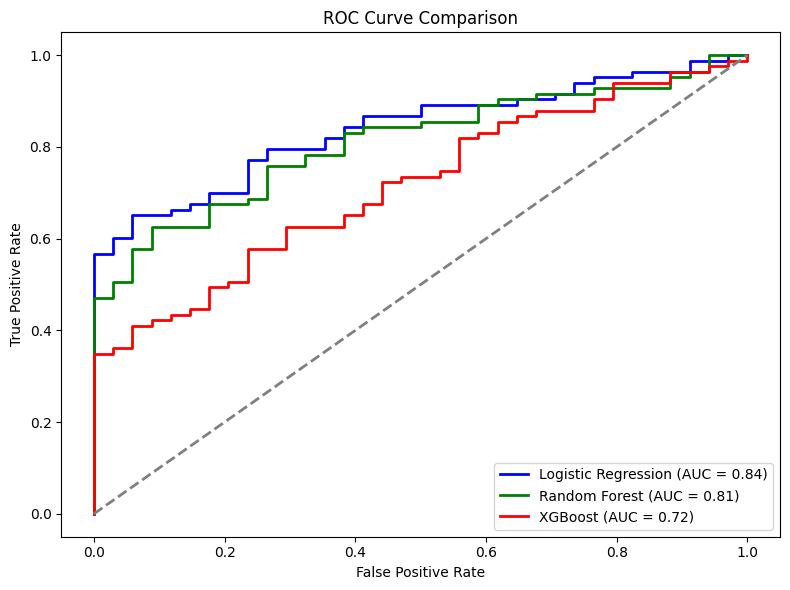

In [ ]:
# --- Load dataset ---
X = liver.drop("Target", axis=1)
y = liver["Target"]

num_cols = ['Age','Total_Bilirubin','Direct_Bilirubin',
            'Alkaline_Phosphotase','Alamine_Aminotransferase',
            'Aspartate_Aminotransferase','Total_Proteins',
            'Albumin','Albumin_and_Globulin_Ratio']
cat_cols = ['Gender','Age_Group']

# --- Preprocessing ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

# --- Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_res, y_train_res)
y_proba_log = log_reg.predict_proba(X_test_prep)[:,1]

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X_train_res, y_train_res)
y_proba_rf = rf.predict_proba(X_test_prep)[:,1]

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb.fit(X_train_res, y_train_res)
y_proba_xgb = xgb.predict_proba(X_test_prep)[:,1]

# --- ROC Curves ---
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, color="blue", lw=2, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, color="green", lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, color="red", lw=2, label=f"XGBoost (AUC = {roc_auc_xgb:.2f})")
plt.plot([0,1], [0,1], color="gray", lw=2, linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#Precision‑Recall Curve Comparison

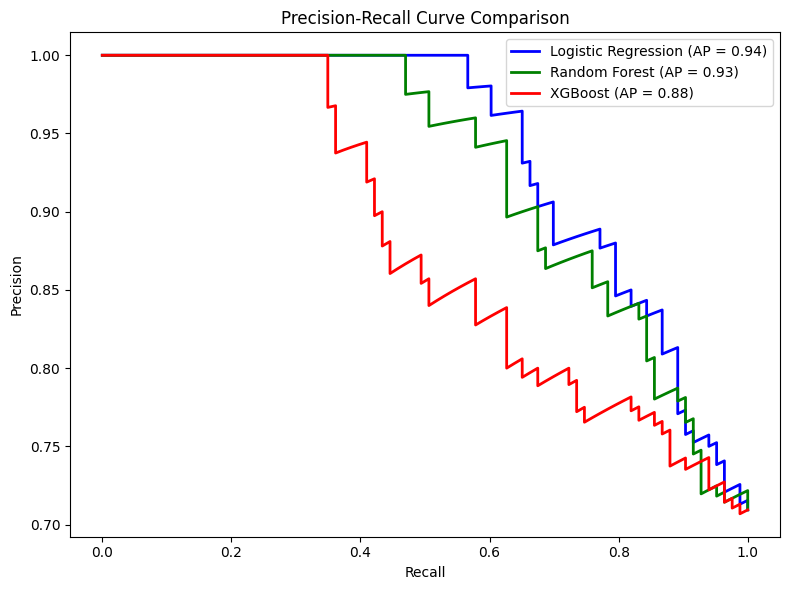

In [ ]:
# Logistic Regression
prec_log, rec_log, _ = precision_recall_curve(y_test, y_proba_log)
ap_log = average_precision_score(y_test, y_proba_log)

# Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)

# XGBoost
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
ap_xgb = average_precision_score(y_test, y_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(rec_log, prec_log, color="blue", lw=2, label=f"Logistic Regression (AP = {ap_log:.2f})")
plt.plot(rec_rf, prec_rf, color="green", lw=2, label=f"Random Forest (AP = {ap_rf:.2f})")
plt.plot(rec_xgb, prec_xgb, color="red", lw=2, label=f"XGBoost (AP = {ap_xgb:.2f})")
plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

#Confusion Matrix

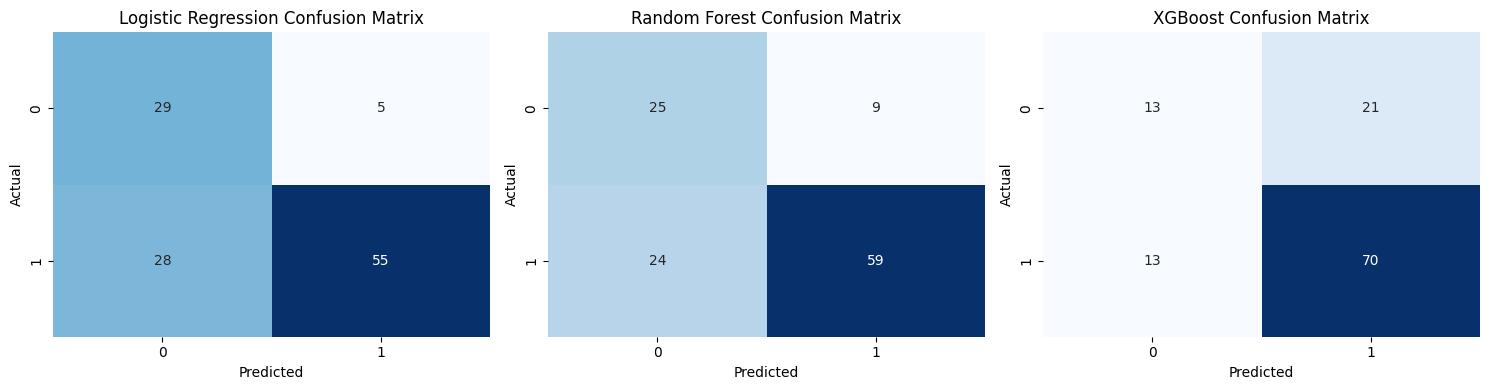

In [ ]:
models = {
    "Logistic Regression": log_reg.predict(X_test_prep),
    "Random Forest": rf.predict(X_test_prep),
    "XGBoost": xgb.predict(X_test_prep)
}

plt.figure(figsize=(15,4))
for i, (name, preds) in enumerate(models.items(), 1):
    cm = confusion_matrix(y_test, preds)
    plt.subplot(1,3,i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

#Feature Importance (Random Forest & XGBoost)

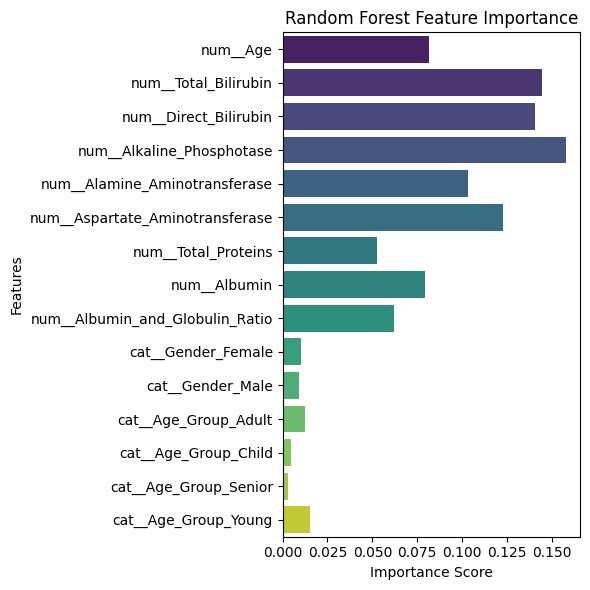

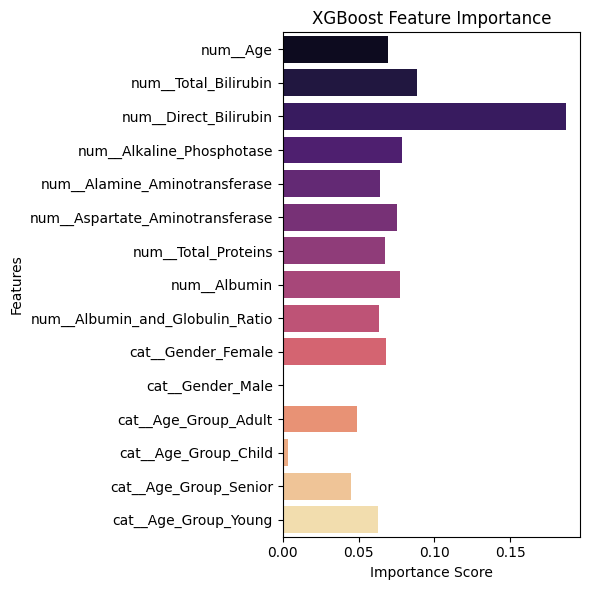

In [ ]:
# Random Forest Feature Importance
importances_rf = rf.feature_importances_
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(6,6))
sns.barplot(x=importances_rf, y=feature_names, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# XGBoost Feature Importance
importances_xgb = xgb.feature_importances_

plt.figure(figsize=(6,6))
sns.barplot(x=importances_xgb, y=feature_names, palette="magma")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#Shap Values

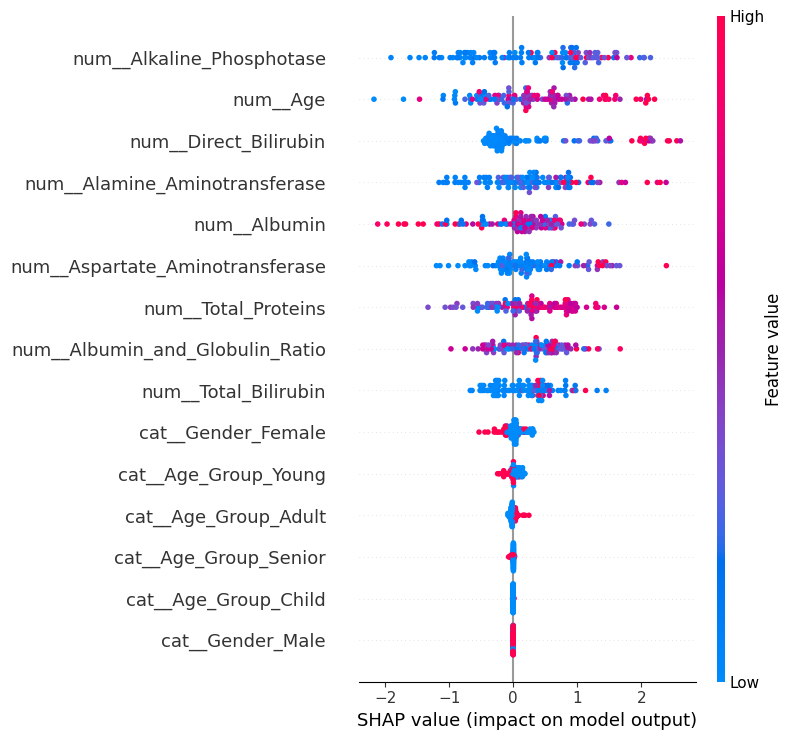

In [ ]:
# Explain XGBoost predictions
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_prep)

# Summary plot
shap.summary_plot(shap_values, X_test_prep, feature_names=feature_names)

#Final Comparision Table

In [ ]:
# Predictions
y_pred_log = log_reg.predict(X_test_prep)
y_pred_rf = rf.predict(X_test_prep)
y_pred_xgb = xgb.predict(X_test_prep)

# Probabilities for ROC-AUC
y_proba_log = log_reg.predict_proba(X_test_prep)[:,1]
y_proba_rf = rf.predict_proba(X_test_prep)[:,1]
y_proba_xgb = xgb.predict_proba(X_test_prep)[:,1]

# Collect metrics
results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ]
}

# Convert to DataFrame
comparison_df = pd.DataFrame(results)
print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.717949   0.916667  0.662651  0.769231  0.838767
1        Random Forest  0.717949   0.867647  0.710843  0.781457  0.810418
2              XGBoost  0.709402   0.769231  0.843373  0.804598  0.716159


#Learning Curves (XGBoost & Random Forest)

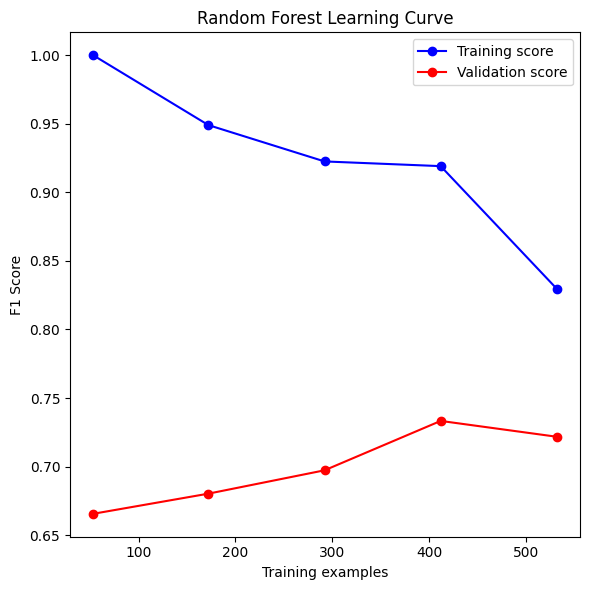

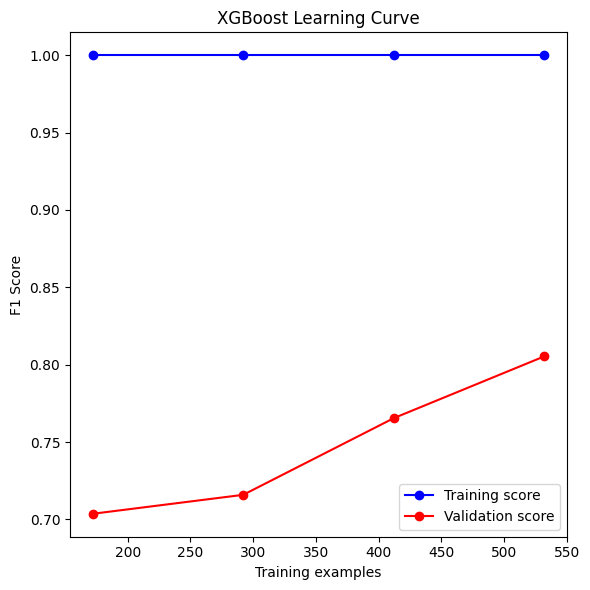

In [ ]:
def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(6,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="red", label="Validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("F1 Score")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# Random Forest
plot_learning_curve(rf, X_train_res, y_train_res, "Random Forest Learning Curve")

# XGBoost
plot_learning_curve(xgb, X_train_res, y_train_res, "XGBoost Learning Curve")

#Cross‑Validation Scores

In [ ]:
# Logistic Regression
cv_log = cross_val_score(log_reg, X_train_res, y_train_res, cv=5, scoring='f1')
print("Logistic Regression CV F1:", cv_log.mean(), "+/-", cv_log.std())

# Random Forest
cv_rf = cross_val_score(rf, X_train_res, y_train_res, cv=5, scoring='f1')
print("Random Forest CV F1:", cv_rf.mean(), "+/-", cv_rf.std())

# XGBoost
cv_xgb = cross_val_score(xgb, X_train_res, y_train_res, cv=5, scoring='f1')
print("XGBoost CV F1:", cv_xgb.mean(), "+/-", cv_xgb.std())

Logistic Regression CV F1: 0.6487722366758941 +/- 0.040126220767124625
Random Forest CV F1: 0.7197139344453922 +/- 0.04801905471579454
XGBoost CV F1: 0.8229867198678033 +/- 0.06900207791478989


#Calibration Curves (Probability Reliability)

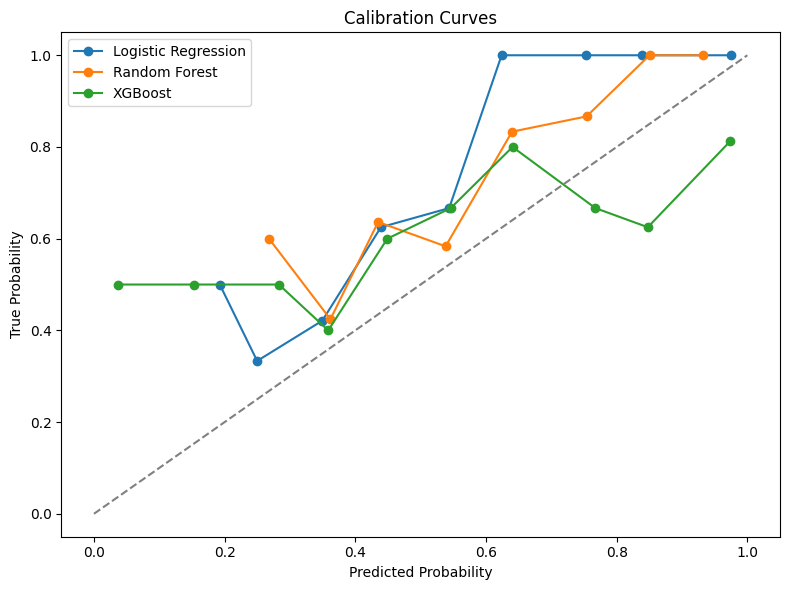

In [ ]:
def plot_calibration_curve(y_true, y_proba, name):
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.figure(figsize=(8,6))
plot_calibration_curve(y_test, y_proba_log, "Logistic Regression")
plot_calibration_curve(y_test, y_proba_rf, "Random Forest")
plot_calibration_curve(y_test, y_proba_xgb, "XGBoost")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.title("Calibration Curves")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.legend()
plt.tight_layout()
plt.show()

#Project Findings

* **Logistic Regression:** High precision, interpretable, but recall is weaker.
* **Random Forest:** Balanced precision and recall, robust baseline.
* **XGBoost:** Best F1 score after tuning, strong predictive power.
* **SMOTE + Hyperparameter tuning** improved all models, showing dataset imbalance was a key challenge.

#Suggestions


*  Use XGBoost with SMOTE as the primary model for maximum predictive performance.
*  Keep Random Forest as a robust baseline model.
*  Retain Logistic Regression with threshold tuning for interpretability, especially in medical contexts.

*  Include ROC, Precision‑Recall, Confusion Matrices, Feature Importance, SHAP, Calibration Curves for credibility.
*  Add cross‑validation to prove stability.

#Limitation

* **Logistic Regression:** linear boundaries, sensitive to imbalance.
* **Random Forest:** less interpretable, slower with many trees.
* **XGBoost:** requires careful hyperparameter tuning, less interpretable.
* **SMOTE:** may introduce synthetic noise if minority samples are very few.
* **Cross‑validation:** computationally heavy.



#Summary

*  Logistic Regression: interpretable but needs SMOTE + threshold tuning.
* Random Forest: robust and balanced, good baseline.
* XGBoost: fastest, most accurate, but complex to tune.
* Together, they provide a comprehensive evaluation framework.

#Conclusion

For the liver dataset:
* XGBoost with SMOTE emerges as the best performing model, offering speed, accuracy, and scalability.

* Random Forest with SMOTE provides robustness and balanced predictions.
* Logistic Regression with threshold tuning adds interpretability, valuable in medical decision contexts.
* Using all three models strengthens the credibility of the project by combining accuracy, robustness, and transparency.